In [270]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from typing import TypedDict, Annotated
from langchain_core.output_parsers import StrOutputParser
import operator

load_dotenv()

True

In [271]:
# model
model = ChatOpenAI(model="gpt-4.1-mini")

parser = StrOutputParser()


In [272]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(
        description='Detailed feedback for the essay'
    )
    score: int = Field(
        ge=0,
        le=10,
        description='Score out of 10'
    )

In [273]:
structured_model = model.with_structured_output(EvaluationSchema)

In [274]:
# define state


class EssayState(TypedDict):

    essay_text: str
    clearity_of_thoughts_feedback: str
    depth_of_analysis_feedback: str
    language_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [275]:
def evaluate_lang(state: EssayState):
    essay_text = state["essay_text"]

    prompt = PromptTemplate(
        template="""
        On the basis of {essay_text} give me a language feedback and a score.
        """,
        input_variables=["essay_text"],
    )

    chain = prompt | structured_model

    res = chain.invoke({"essay_text": essay_text})

    return {"language_feedback": res.feedback, "individual_scores": [res.score]}

In [276]:
def cot(state: EssayState):
    essay_text = state["essay_text"]

    prompt = PromptTemplate(
        template="""
        On the basis of {essay_text} give me a clearity of thoughts feedback and score.
        """,
        input_variables=["essay_text"],
    )

    chain = prompt | structured_model

    res = chain.invoke({"essay_text": essay_text})

    return {
        "clearity_of_thoughts_feedback": res.feedback,
        "individual_scores": [res.score],
    }

In [277]:
def doa(state: EssayState):
    essay_text = state["essay_text"]

    prompt = PromptTemplate(
        template="""
        On the basis of {essay_text} give me a depth of analysis feedback and a score.
        """,
        input_variables=["essay_text"],
    )

    chain = prompt | structured_model

    res = chain.invoke({"essay_text": essay_text})

    return {
        "depth_of_analysis_feedback": res.feedback,
        "individual_scores": [res.score],
    }

In [278]:
def final_eval(state: EssayState):

    language_feedback = state["language_feedback"]
    clearity_of_thoughts_feedback = state["clearity_of_thoughts_feedback"]
    depth_of_analysis_feedback = state["depth_of_analysis_feedback"]
    individual_scores = state["individual_scores"]

    prompt = PromptTemplate(
        template="""
        On the basis of language feedback -> {language_feedback} \n 
        clearity of thoughts feedback -> {clearity_of_thoughts_feedback} \n 
        depth_of_analysis_feedback -> {depth_of_analysis_feedback} \n
        """,
        input_variables=["language_feedback", "clearity_of_thoughts_feedback", "depth_of_analysis_feedback"],
    )

    chain = prompt | model | parser

    res = chain.invoke(
        {
            "language_feedback": language_feedback,
            "clearity_of_thoughts_feedback": clearity_of_thoughts_feedback,
            "depth_of_analysis_feedback": depth_of_analysis_feedback,
        }
    )

        
    avg_score = sum(individual_scores) / len(individual_scores)
    
    # print(res)

    return {"overall_feedback": res, "avg_score": avg_score}

In [279]:
# define a graph
graph = StateGraph(EssayState)

# add nodes
graph.add_node("evaluate_lang", evaluate_lang)
graph.add_node("clearity_of_thoughts", cot)
graph.add_node("depth_of_analysis", doa)
graph.add_node("final_evaluation", final_eval)

# add edges
graph.add_edge(START, "evaluate_lang")
graph.add_edge(START, "clearity_of_thoughts")
graph.add_edge(START, "depth_of_analysis")

graph.add_edge("evaluate_lang", "final_evaluation")
graph.add_edge("clearity_of_thoughts", "final_evaluation")
graph.add_edge("depth_of_analysis", "final_evaluation")

graph.add_edge('final_evaluation', END)
graph.add_edge('final_evaluation', END)
graph.add_edge('final_evaluation', END)

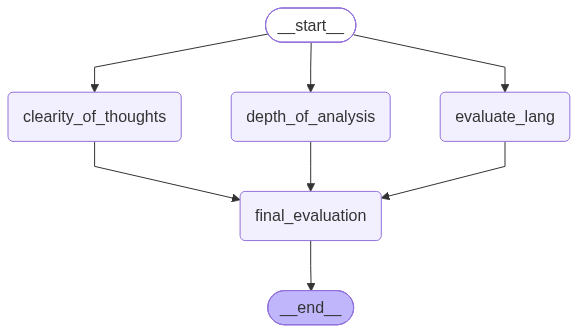

In [280]:
workflow = graph.compile()
workflow

In [281]:
essay_text = """
# Cats

Cats are one of the most popular pets in the world. They are loved for their intelligence, playful nature, and independence. For thousands of years, cats have lived with humans, providing companionship and helping control pests.

Cats are naturally curious and enjoy exploring their surroundings. They spend a lot of time grooming themselves, which keeps them clean and healthy. They are also easy to care for because they can be litter-trained and require relatively little maintenance.

Although cats are independent, they can form strong bonds with their owners. They often show affection by purring, sitting close to people, or following them around the house. Their calm presence can help people feel relaxed and happy.

Cats come in many breeds, colors, and sizes, each with its own unique personality. Whether playful or quiet, every cat is special in its own way.

In conclusion, cats are intelligent, clean, and affectionate animals. Their companionship and charming behavior make them wonderful pets for people of all ages.
"""
initial_state = {
    'essay_text': essay_text
}

In [282]:
final_state = workflow.invoke(initial_state)
print(final_state)

{'essay_text': '\n# Cats\n\nCats are one of the most popular pets in the world. They are loved for their intelligence, playful nature, and independence. For thousands of years, cats have lived with humans, providing companionship and helping control pests.\n\nCats are naturally curious and enjoy exploring their surroundings. They spend a lot of time grooming themselves, which keeps them clean and healthy. They are also easy to care for because they can be litter-trained and require relatively little maintenance.\n\nAlthough cats are independent, they can form strong bonds with their owners. They often show affection by purring, sitting close to people, or following them around the house. Their calm presence can help people feel relaxed and happy.\n\nCats come in many breeds, colors, and sizes, each with its own unique personality. Whether playful or quiet, every cat is special in its own way.\n\nIn conclusion, cats are intelligent, clean, and affectionate animals. Their companionship a

In [283]:
print(final_state['clearity_of_thoughts_feedback'])

The essay provides a clear and concise overview of cats, highlighting their popularity, characteristics, and relationship with humans. The structure is logical, beginning with an introduction to cats as pets, followed by details about their behavior, care needs, and emotional bonds with owners. The language is straightforward and appropriate, making the content accessible. However, the essay could be improved by including more specific examples or details about different breeds or anecdotes to make it more engaging. Additionally, some sentences could be varied in structure to enhance readability. Overall, the essay effectively conveys its message with clarity and organization.
